# Steam Game Review Analysis: Machine Learning Implementation

Prabhleen Gill

In [12]:
import nltk
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import re

In [ ]:
import tensorflow as tf

### Load and clean data

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("filipkin/steam-reviews")

print("Path to dataset files:", path)

/opt/anaconda3/envs/gamereview_notebook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/prabhleengill/.cache/kagglehub/datasets/filipkin/steam-reviews/versions/6


In [16]:
# load dataset
df = pd.read_csv(f"{path}/output.csv")

In [17]:
df.shape

(201151, 5)

In [18]:
df.head()

,id,app_id,content,author_id,is_positive
0,181331361,100,At least its a counter strike -1/100,76561199556485100,Negative
1,180872601,100,Uh... So far my playthrough has not been great...,76561199230620391,Negative
2,177836246,100,Better mechanics than cs2,76561198417690647,Negative
3,177287444,100,buggy mess and NOT fun to play at all,76561199077268730,Negative
4,176678990,100,"Whoever came up with this, is gonna fucking ge...",76561199104544266,Negative


### Data Preparation & Cleaning

In [19]:
# Clean text

# drop id columns
df = df.drop(['author_id', 'app_id', 'id'], axis = 1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201151 entries, 0 to 201150
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   content      200723 non-null  str  
 1   is_positive  201151 non-null  str  
dtypes: str(2)
memory usage: 3.1 MB


In [20]:
# Handle missing/incorrect data
df = df.dropna()
df.isnull().sum()

content        0
is_positive    0
dtype: int64

In [21]:
# cleaning content
import unicodedata

def clean_text(text):
    text = str(text)
    text = unicodedata.normalize("NFKD", text) # normalize unicode
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = text.lower() # lower case text
    text = re.sub(r"http\S+", " ", text) # remove URLs
    text = text.replace('"', ' ').replace("'", " ") # remove leftover quotes
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9\s.,!?]", " ", text) # remove extra characters
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    return text

In [22]:
df['clean_content'] = df['content'].apply(clean_text)
df = df[df['clean_content'].str.count(r'[a-zA-Z]') > 5]
df = df.reset_index(drop=True)

In [23]:
# Remove punctuations
df['clean_no_punct'] = df['clean_content'].apply(lambda x: re.sub(r'[^a-zA-ZÀ-ÿ0-9\s]', ' ', x))

In [24]:
# tokenize clean_no_punct

df['tokens'] = df['clean_no_punct'].str.split()

In [25]:
# Add features

# char_count: number of characters in content

df['char_count'] = df['content'].str.len()

In [26]:
# word_count: number of words in content
df['word_count'] = df['content'].str.split().str.len()

In [27]:
# avg_word_length: average length of words in content
df['avg_word_length'] = df['clean_content'].apply(lambda x: np.mean([len(word) for word in x.split()]))

In [28]:
df.head()

,content,is_positive,clean_content,clean_no_punct,tokens,char_count,word_count,avg_word_length
0,At least its a counter strike -1/100,Negative,at least its a counter strike 1 100,at least its a counter strike 1 100,"[at, least, its, a, counter, strike, 1, 100]",36,7,3.500000
1,Uh... So far my playthrough has not been great...,Negative,uh... so far my playthrough has not been great...,uh so far my playthrough has not been great...,"[uh, so, far, my, playthrough, has, not, been,...",230,42,4.476190
2,Better mechanics than cs2,Negative,better mechanics than cs2,better mechanics than cs2,"[better, mechanics, than, cs2]",25,4,5.500000
3,buggy mess and NOT fun to play at all,Negative,buggy mess and not fun to play at all,buggy mess and not fun to play at all,"[buggy, mess, and, not, fun, to, play, at, all]",37,9,3.222222
4,"Whoever came up with this, is gonna fucking ge...",Negative,"whoever came up with this, is gonna fucking ge...",whoever came up with this is gonna fucking ge...,"[whoever, came, up, with, this, is, gonna, fuc...",76,14,4.500000


### Word Analysis

In [29]:
# get sentiment scores using VADER
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['clean_content'].apply(lambda x: sia.polarity_scores(x)['compound'])

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/prabhleengill/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [30]:
# convert is_positive into integer values
df['is_positive_int'] = df['is_positive'].map({'Positive': 1, 'Negative': 0})

In [31]:
df.head()

,content,is_positive,clean_content,clean_no_punct,tokens,char_count,word_count,avg_word_length,sentiment_score,is_positive_int
0,At least its a counter strike -1/100,Negative,at least its a counter strike 1 100,at least its a counter strike 1 100,"[at, least, its, a, counter, strike, 1, 100]",36,7,3.500000,-0.1280,0
1,Uh... So far my playthrough has not been great...,Negative,uh... so far my playthrough has not been great...,uh so far my playthrough has not been great...,"[uh, so, far, my, playthrough, has, not, been,...",230,42,4.476190,-0.8357,0
2,Better mechanics than cs2,Negative,better mechanics than cs2,better mechanics than cs2,"[better, mechanics, than, cs2]",25,4,5.500000,0.4404,0
3,buggy mess and NOT fun to play at all,Negative,buggy mess and not fun to play at all,buggy mess and not fun to play at all,"[buggy, mess, and, not, fun, to, play, at, all]",37,9,3.222222,-0.7382,0
4,"Whoever came up with this, is gonna fucking ge...",Negative,"whoever came up with this, is gonna fucking ge...",whoever came up with this is gonna fucking ge...,"[whoever, came, up, with, this, is, gonna, fuc...",76,14,4.500000,-0.7269,0


### Classical Machine Learning

In [53]:
df2 = df.copy()

In [54]:
df2 = df2[df2["word_count"] >= 3]

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

X = df2['clean_content']
y = df2['is_positive_int']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



======================== Logistic Regression ========================
Accuracy: 0.8740
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     15574
           1       0.86      0.88      0.87     15131

    accuracy                           0.87     30705
   macro avg       0.87      0.87      0.87     30705
weighted avg       0.87      0.87      0.87     30705



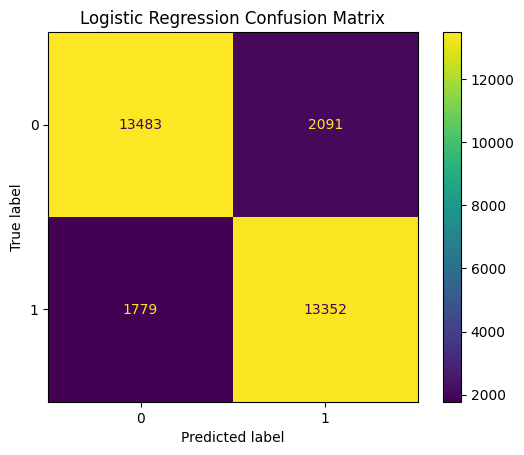

In [56]:
# Logistic Regression
log_reg = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=5000,
        C=4
    ))
])

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
acc = accuracy_score(y_test, y_pred_lr)
print("\n======================== Logistic Regression ========================")
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


======================== LinearSVC ========================
Accuracy: 0.8672
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     15574
           1       0.86      0.88      0.87     15131

    accuracy                           0.87     30705
   macro avg       0.87      0.87      0.87     30705
weighted avg       0.87      0.87      0.87     30705



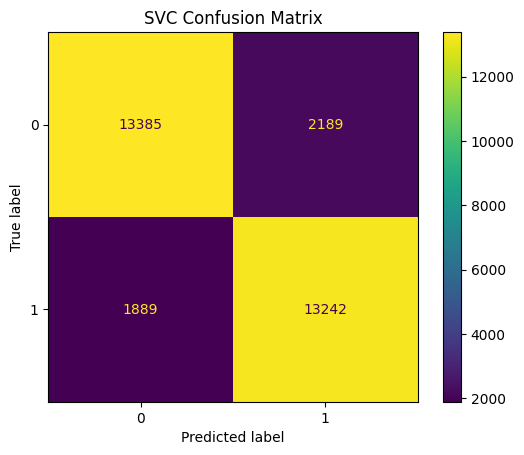

In [60]:
# Support Vector Machine
svc = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(C=1.0))
])

svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
acc = accuracy_score(y_test, y_pred_svc)
print("\n======================== LinearSVC ========================")
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred_svc))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc)
plt.title("SVC Confusion Matrix")
plt.show()


======================== Multinomial Naive Bayes ========================
Accuracy: 0.8558
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     15574
           1       0.85      0.86      0.85     15131

    accuracy                           0.86     30705
   macro avg       0.86      0.86      0.86     30705
weighted avg       0.86      0.86      0.86     30705



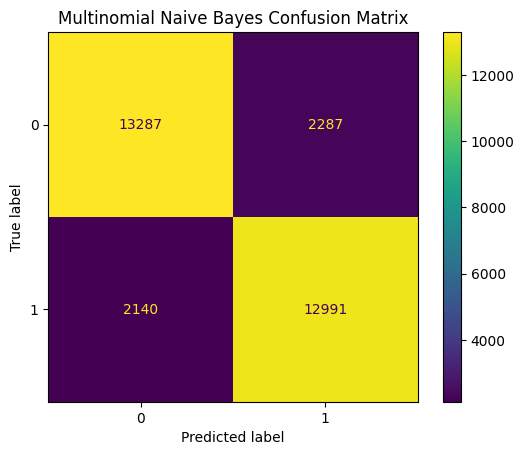

In [58]:
# Multinomial Naive Bayes
mnb = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ('clf', MultinomialNB())
])

mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
acc = accuracy_score(y_test, y_pred_mnb)
print("\n======================== Multinomial Naive Bayes ========================")
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred_mnb))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mnb)
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

### Deep Learning

LSTM

In [36]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

In [62]:
# split data
X = df2['clean_content'].astype(str).values
y = df2['is_positive_int'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [63]:
# Tokenizing & padding
vocab_size = 20000 # max number of words to keep
max_len = 200 # max tokens per review

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

In [64]:
embedding_dim = 100

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(256, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/opt/anaconda3/envs/gamereview_notebook/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [65]:
# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [67]:
# Train model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=256,
    verbose=1
)

Epoch 1/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 92s 190ms/step - accuracy: 0.7900 - loss: 0.4547
Epoch 2/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 90s 187ms/step - accuracy: 0.8508 - loss: 0.3492
Epoch 3/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 92s 192ms/step - accuracy: 0.8672 - loss: 0.3129
Epoch 4/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 94s 195ms/step - accuracy: 0.8833 - loss: 0.2781
Epoch 5/5
480/480 ━━━━━━━━━━━━━━━━━━━━ 94s 197ms/step - accuracy: 0.8949 - loss: 0.2487


960/960 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step
Test accuracy: 0.8603159094609998
              precision    recall  f1-score   support

           0       0.86      0.87      0.86     15574
           1       0.86      0.85      0.86     15131

    accuracy                           0.86     30705
   macro avg       0.86      0.86      0.86     30705
weighted avg       0.86      0.86      0.86     30705



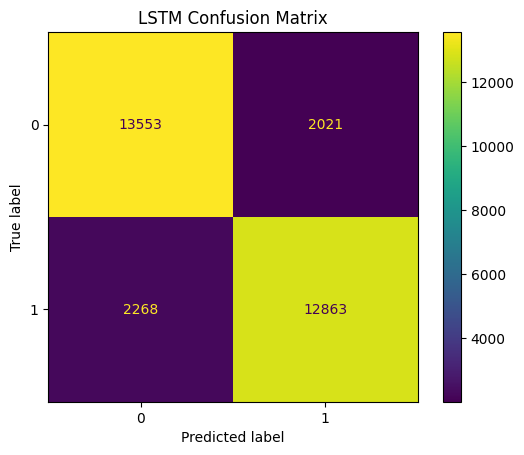

In [68]:
# Evaluate model
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

print("Test accuracy:", (y_pred == y_test).mean())
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("LSTM Confusion Matrix")
plt.show()

### DistilBERT

In [150]:
df_small = df.sample(10000, random_state=42)

In [151]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_small[["clean_content", "is_positive_int"]],
    test_size=0.2,
    random_state=42,
    stratify=df_small["is_positive_int"]
)

In [152]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [153]:
train_dataset = train_dataset.rename_column("is_positive_int", "labels")
test_dataset = test_dataset.rename_column("is_positive_int", "labels")

In [154]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [155]:
def tokenize(batch):
    return tokenizer(
        batch["clean_content"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map: 100%|████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 35891.09 examples/s]


In [156]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights: 100%|██████████████████████████████████████████████████| 100/100 [00:00<00:00, 7338.86it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [157]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [158]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./distilbert-steam-sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/opt/anaconda3/envs/gamereview_notebook/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.396921,0.370892,0.858000,0.833028,0.899010,0.864762
2,0.280326,0.460188,0.861000,0.869697,0.852475,0.861000
3,0.178073,0.608079,0.852000,0.864286,0.838614,0.851256


Writing model shards: 100%|███████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.64it/s]
/opt/anaconda3/envs/gamereview_notebook/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|███████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.93it/s]
/opt/anaconda3/envs/gamereview_notebook/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|███████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.38it/s]


TrainOutput(global_step=3000, training_loss=0.30058454132080076, metrics={'train_runtime': 861.6187, 'train_samples_per_second': 27.855, 'train_steps_per_second': 3.482, 'total_flos': 794804391936000.0, 'train_loss': 0.30058454132080076, 'epoch': 3.0})

In [159]:
results = trainer.evaluate()

/opt/anaconda3/envs/gamereview_notebook/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.178073,0.370892,3,0.858000,0.833028,0.899010,0.864762


In [160]:
results

{'eval_loss': 0.3708922266960144,
 'eval_accuracy': 0.858,
 'eval_precision': 0.8330275229357799,
 'eval_recall': 0.899009900990099,
 'eval_f1': 0.8647619047619047}

### Results

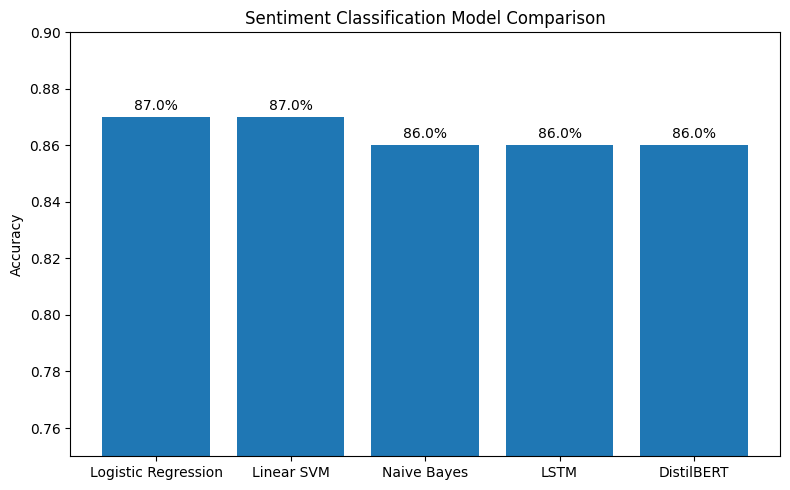

In [164]:
ml_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes",
        "LSTM",
        "DistilBERT"
    ],
    "Accuracy": [0.87, 0.87, 0.86, 0.86, 0.86]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(ml_results["Model"], ml_results["Accuracy"])

plt.ylim(0.75, 0.90)
plt.ylabel("Accuracy")
plt.title("Sentiment Classification Model Comparison")
plt.xticks()

plt.bar_label(bars, labels=[f"{x:.1%}" for x in ml_results["Accuracy"]], padding=3)

plt.tight_layout()
plt.show()